c:\Users\panag\anaconda3\envs\optimization\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Best model: RandomForest
Extracted parameters → a_t = 163208.6074, b_t = 3.4667


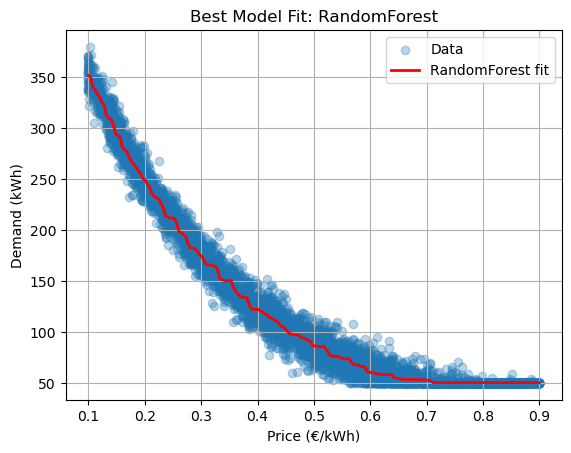

Test set → RMSE: 9.82, MAE: 6.69, R²: 0.9869


In [11]:
import numpy as np
import pandas as pd
import gym
from gym import spaces
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import curve_fit
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# -----------------------------
# Example usage
# -----------------------------
if __name__ == '__main__':
    df = generate_data()
    results, best, sx, sy, Xte, yte = train_models(df)
    print('Best model:', best)

    # Extract exponential parameters a_t, b_t
    sample_P = np.array([[0.15], [0.30]])
    if best == 'Exponential':
        a_t, b_t = results[best]['model'].a_, results[best]['model'].b_
    else:
        if best == 'RidgePoly2':
            d = results[best]['model'].predict(sx.transform(sample_P))
        elif best == 'RandomForest':
            d = results[best]['model'].predict(sample_P).reshape(-1,1)
        else:  # NeuralNet
            d = results[best]['model'].predict(sx.transform(sample_P)).reshape(-1,1)
        d = sy.inverse_transform(np.array(d).reshape(-1,1))
        d1, d2 = d[0,0], d[1,0]
        P1, P2 = 0.15, 0.30
        b_t = np.log(d1/d2)/(P2-P1)
        a_t = d1/np.exp(-b_t*P1)

    print(f"Extracted parameters → a_t = {a_t:.4f}, b_t = {b_t:.4f}")

    # Plot data and best model fit
    plt.scatter(df['price'], df['demand'], alpha=0.3, label='Data')
    xs = np.linspace(0.10, 0.90, 200).reshape(-1,1)
    if best == 'Exponential':
        ys = a_t * np.exp(-b_t * xs)
        plt.plot(xs, ys, 'r-', lw=2, label=f"{best} fit (a={a_t:.2f}, b={b_t:.2f})")
    else:
        if best == 'RidgePoly2':
            ys_pred = sy.inverse_transform(results[best]['model'].predict(sx.transform(xs)).reshape(-1,1))
        elif best == 'RandomForest':
            ys_pred = results[best]['model'].predict(xs).reshape(-1,1)
        else:  # NeuralNet
            ys_pred = sy.inverse_transform(results[best]['model'].predict(sx.transform(xs)).reshape(-1,1))
        plt.plot(xs, ys_pred, 'r-', lw=2, label=f"{best} fit")
    plt.title(f"Best Model Fit: {best}")
    plt.xlabel("Price (€/kWh)")
    plt.ylabel("Demand (kWh)")
    plt.legend(); plt.grid(True); plt.show()

    # Calculate and print error metrics on test set
    if best == 'Exponential':
        y_pred_test = results[best]['model'].predict(Xte)
    else:
        if best == 'RidgePoly2':
            y_pred_test = sy.inverse_transform(results[best]['model'].predict(sx.transform(Xte)).reshape(-1,1))
        elif best == 'RandomForest':
            y_pred_test = results[best]['model'].predict(Xte).reshape(-1,1)
        else:  # NeuralNet
            y_pred_test = sy.inverse_transform(results[best]['model'].predict(sx.transform(Xte)).reshape(-1,1))
    rmse_test = np.sqrt(mean_squared_error(yte, y_pred_test))
    mae_test = mean_absolute_error(yte, y_pred_test)
    r2_test = r2_score(yte, y_pred_test)
    print(f"Test set → RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R²: {r2_test:.4f}")



